# Quantum Annealing: Noiseless Simulation

This notebook studies spectral properties of a simple adiabatic Ising evolution in the absence of noise.


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..')) 
from solver.quantum_solver.dwave_simulator import DwaveSimulator

def generate_random_ising(n, h_range=(-1, 1), J_range=(-2, 2)):
    # Create a random Ising problem
    s = sp.symbols(f's0:{n}')
    expr = 0
    expr += 0.0001 * s[n-1] 
    
    for i in range(n):
        expr += np.random.uniform(h_range[0], h_range[1]) * s[i]
    for i in range(n):
        for j in range(i+1, n):
            expr += np.random.uniform(J_range[0], J_range[1]) * s[i] * s[j]
    return expr


<Axes: title={'center': 'Spectral gap along the annealing schedule'}, xlabel='Annealing step', ylabel='Gap'>

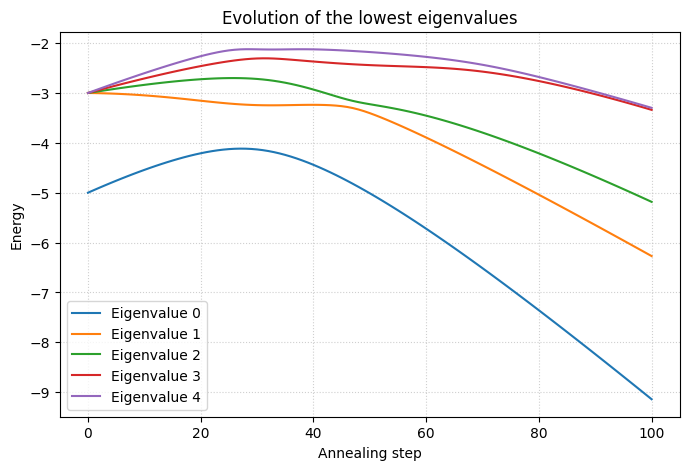

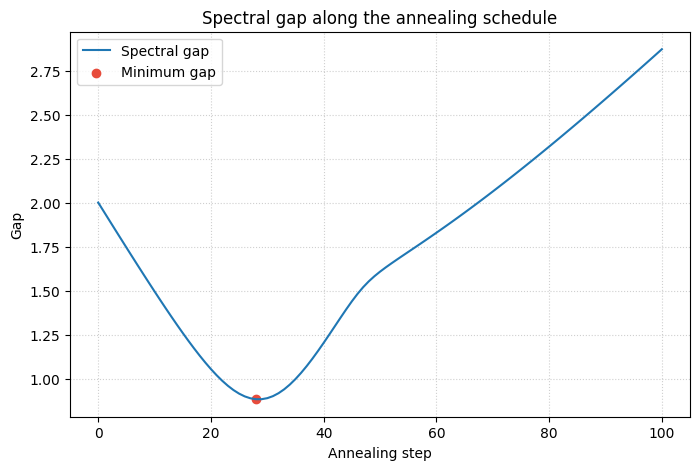

In [2]:
sim = DwaveSimulator()
n_small = 5 
ising_prob = generate_random_ising(n_small)

eigenvalues_history = sim.simulate_evolution(ising_prob, nb_eigenvalues=5)

# Results
sim.plot_eigenvalues(eigenvalues_history)
sim.plot_spectral_gap(eigenvalues_history)


Size 3 | Average minimum gap: 0.641598
Size 4 | Average minimum gap: 0.529059
Size 5 | Average minimum gap: 0.542359
Size 6 | Average minimum gap: 0.448329
Size 7 | Average minimum gap: 0.397023
Size 8 | Average minimum gap: 0.384670


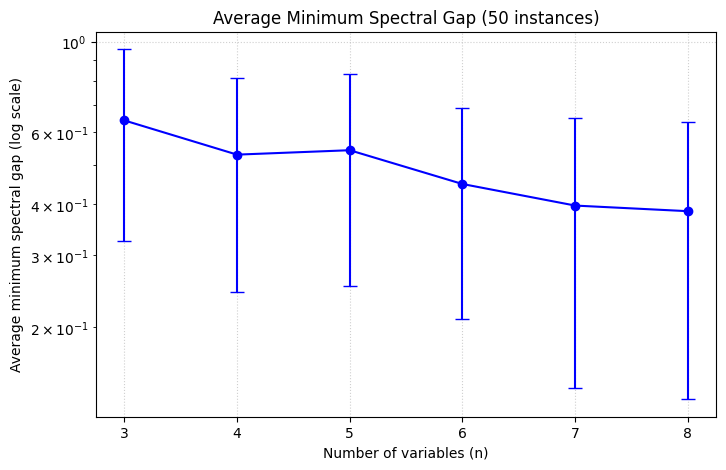

In [3]:

sizes = range(3,9) 
num_instances = 50
avg_min_gaps_by_size = []
std_min_gaps_by_size = []

for n in sizes:
    gaps_for_this_size = []
    for _ in range(num_instances):
        prob = generate_random_ising(n)
        eigenvalues_history = sim.simulate_evolution(prob, nb_eigenvalues=2)
        data = np.array(eigenvalues_history) 
        gap = data[:, 1] - data[:, 0]
        gaps_for_this_size.append(np.min(gap))
    
    avg_min_gaps_by_size.append(np.mean(gaps_for_this_size))
    std_min_gaps_by_size.append(np.std(gaps_for_this_size))
    print(f"Size {n} | Average minimum gap: {np.mean(gaps_for_this_size):.6f}")

plt.figure(figsize=(8, 5))
# Use of errorbar to show dispersion of results
plt.errorbar(sizes, avg_min_gaps_by_size, yerr=std_min_gaps_by_size, marker='o', color='blue', capsize=5)
plt.yscale('log') #
plt.title(f"Average Minimum Spectral Gap ({num_instances} instances)")
plt.xlabel("Number of variables (n)")
plt.ylabel("Average minimum spectral gap (log scale)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Q: Do you observe any difference concerning the spectral gap? How should it scale with the instance size?


Looking at the generated plot, we can observe that the average minimum spectral gap globally decreases as the number of variables increases from 3 to 8. But there is significant variance as it indicated by the large error bars, which is expected since we are averaging over random Ising instances. Theoretically, the spectral gap should scale exponentially downward with the instance size



Scale factor x0.1 | Average minimum gap: 0.123516
Scale factor x0.5 | Average minimum gap: 0.400093
Scale factor x1.0 | Average minimum gap: 0.557512
Scale factor x2.0 | Average minimum gap: 0.677786
Scale factor x10.0 | Average minimum gap: 0.819441


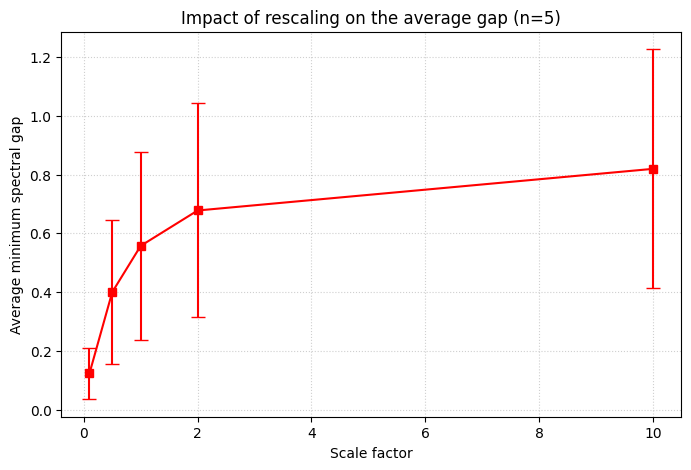

In [4]:
n_test = 5
num_instances = 10
scale_factors = [0.1, 0.5, 1.0, 2.0, 10.0]

avg_gaps_rescaled = []
std_gaps_rescaled = []

base_problems = [generate_random_ising(n_test) for _ in range(num_instances)]

for scale in scale_factors:
    gaps_for_this_scale = []
    
    for base_problem in base_problems:
        rescaled_problem = base_problem * scale
        
        # Simulation
        eigenvalues_history = sim.simulate_evolution(rescaled_problem, nb_eigenvalues=2)
        data = np.array(eigenvalues_history)
        
        # Gap calculation
        gap = data[:, 1] - data[:, 0]
        gaps_for_this_scale.append(np.min(gap))
        
    avg_gaps_rescaled.append(np.mean(gaps_for_this_scale))
    std_gaps_rescaled.append(np.std(gaps_for_this_scale))
    print(f"Scale factor x{scale} | Average minimum gap: {np.mean(gaps_for_this_scale):.6f}")

plt.figure(figsize=(8, 5))
plt.errorbar(scale_factors, avg_gaps_rescaled, yerr=std_gaps_rescaled, marker='s', color='red', capsize=5)
plt.title(f"Impact of rescaling on the average gap (n={n_test})")
plt.xlabel("Scale factor")
plt.ylabel("Average minimum spectral gap")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


Q: In quantum annealers, the programming range of h_i and J_ij values is always finite
(for example hi ∈ [−1, +1] and hi,j ∈ [−2, +2] ). If we need to rescale the values of
one input problem to solve it with a quantum annealer, does it ease or worsen the
resolution of the problem ? Explain why (take a look at the spectral gap) ?

It worsens the resolution. Forcing the weights to fit hardware limits shrinks the minimum spectral gap. A smaller gap makes the quantum system highly fragile and susceptible to noise. It will easily lose its ground state, drastically reducing the chances of finding the optimal solution.